# EDA & Preprocessing
### Replication & Extension of Jha, Qian, Weber & Yang (2024) — *"ChatGPT and Corporate Policies"*

**Course:** Text as Data — NYU, Spring 2026

This notebook merges all raw data sources, explores each one, engineers the variables needed for the scoring pipeline, and saves a clean panel ready for the LLM scorer.

**Data sources:**
- Earnings call transcripts — HuggingFace `kurry/sp500_earnings_transcripts`
- Compustat Quarterly — WRDS `comp.fundq`
- CCM Link — WRDS `crsp.ccmxpf_lnkhist`
- CRSP Monthly — WRDS `crsp.msf`
- Fama-French 5 Factors — WRDS `ff.fivefactors_monthly`
- I/B/E/S Analyst Forecasts — WRDS `ibes.statsum_epsus`

In [1]:
import sys, os
import re

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

import math 
from collections import Counter
from joblib import Parallel, delayed

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from itertools import chain


# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(7524)
sns.set_theme(style='whitegrid', palette='Blues_d')

# project root on path so data/config.py is importable
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'data'))
DATA = os.path.join('..', 'data')

# raw data paths
TRANSCRIPTS_PATH = os.path.join(DATA, 'transcripts', 'transcripts.parquet')
COMPUSTAT_PATH = os.path.join(DATA, 'financials', 'compustat_quarterly.parquet')
CCM_PATH = os.path.join(DATA, 'financials', 'ccm_link.parquet')
CRSP_PATH = os.path.join(DATA, 'financials', 'crsp_monthly.parquet')
FF5_PATH = os.path.join(DATA, 'financials', 'ff5_factors_monthly.parquet')
IBES_PATH = os.path.join(DATA, 'financials', 'ibes_consensus.parquet')

## 1. Transcripts

In [2]:
# read the data
tr = pd.read_parquet(TRANSCRIPTS_PATH)

# re-derive year and quarter from date — the stored columns may reflect fiscal calendar;
# we want calendar-based values to match against Compustat fyearq/fqtr downstream
tr['date'] = pd.to_datetime(tr['date'])
tr['year'] = tr['date'].dt.year
tr['quarter'] = tr['date'].dt.quarter

print(f"Shape: {tr.shape}")
print(f"Columns: {tr.columns.tolist()}")
tr.head(3)

Shape: (33362, 8)
Columns: ['symbol', 'quarter', 'year', 'date', 'content', 'structured_content', 'company_name', 'company_id']


,symbol,quarter,year,date,content,structured_content,company_name,company_id
0,A,4,2020,2020-11-23 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0000
1,A,3,2020,2020-08-18 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0000
2,A,2,2020,2020-05-21 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0000


| Field | Type | Description |
|---|---|---|
| `symbol` | string | Stock ticker (primary join key) |
| `company_name` | string | Full company name — ~27% missing, not used for joins |
| `company_id` | float | Capital IQ identifier — ~27% missing |
| `year` | int | Calendar year of the earnings call |
| `quarter` | int | Calendar quarter (1–4) |
| `date` | datetime | Exact call date and time |
| `content` | string | Full raw transcript text |
| `structured_content` | object | Array of `{speaker, text}` objects — speaker-level segmentation |

**33,362 transcripts across 685 companies, 2005–2025.** `symbol` and `content` are complete. `structured_content` covers 100% of rows — this is the field we will use to split management presentation from Q&A.

In [3]:
# null counts and dataset coverage
print("=== Nulls ===")
print(tr.isnull().sum())
print()
print("=== Coverage ===")
print(f"Companies: {tr['symbol'].nunique()}")
print(f"Date range: {tr['date'].min().date()} to {tr['date'].max().date()}")
print(f"Total calls: {len(tr):,}")
print(f"Avg per company: {len(tr) / tr['symbol'].nunique():.1f}")

=== Nulls ===
symbol                   0
quarter                  0
year                     0
date                     0
content                  0
structured_content       0
company_name          8985
company_id            8985
dtype: int64

=== Coverage ===
Companies: 685
Date range: 2005-10-13 to 2025-05-15
Total calls: 33,362
Avg per company: 48.7


The only missing data is in `company_name` and `company_id` (~8,985 rows each, ~27%). These are supplementary fields — all joins use `symbol`, which is complete. Coverage spans 20 years with an average of ~49 calls per company, meaning most companies have close to full quarterly coverage.

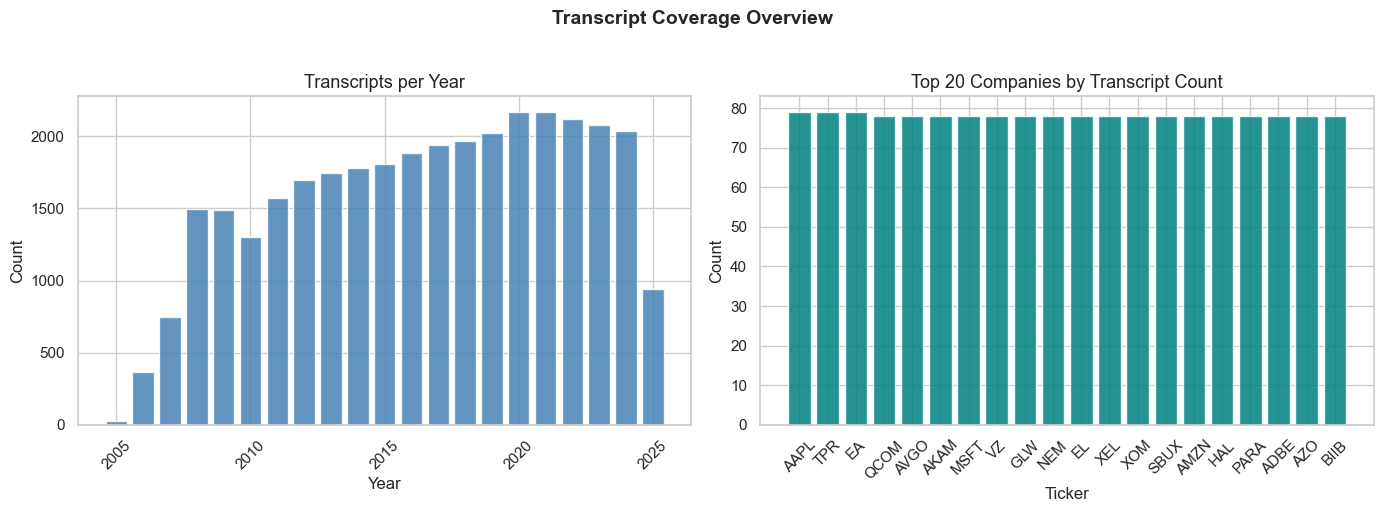

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# transcripts per year
by_year = tr.groupby('year').size()
axes[0].bar(by_year.index, by_year.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Transcripts per Year', fontsize=13)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# top 20 companies by call count
top20 = tr.groupby('symbol').size().sort_values(ascending=False).head(20)
axes[1].bar(top20.index, top20.values, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Top 20 Companies by Transcript Count', fontsize=13)
axes[1].set_xlabel('Ticker', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Transcript Coverage Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The dataset's transcript coverage expands sharply from 2005 to the early 2010s, then remains consistently high from the mid-2010s through the early 2020s, peaking around 2020 to 2021. The apparent drop in 2025 is likely due to incomplete-year coverage rather than a true decline. Among the top 20 firms, transcript counts are nearly identical, which suggests stable and repeated coverage of a core group of large firms rather than major differences across those companies.

=== Content length (chars) ===
count   33362.0000
mean     9170.0000
std      2232.0000
min         0.0000
25%      8093.0000
50%      9196.0000
75%     10224.0000
max     42971.0000


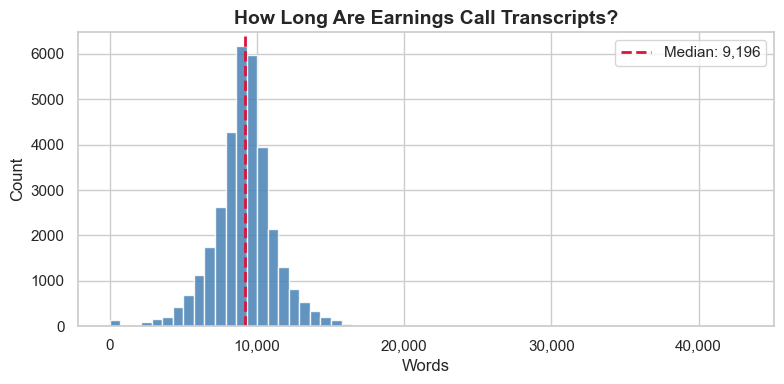

In [5]:
# compute word length for each transcript
tr['content_len'] = tr['content'].str.split().str.len()

# summary stats
print("=== Content length (chars) ===")
print(tr['content_len'].describe().round(0).to_string())

# compute median for reference line
median_len = tr['content_len'].median()

# distribution plot
plt.figure(figsize=(8, 4))
plt.hist(tr['content_len'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(median_len, color='crimson', linewidth=2, linestyle='--', label=f'Median: {int(median_len):,}')

# aesthetics
plt.title('How Long Are Earnings Call Transcripts?', fontsize=14, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

The median transcript sits at **~9, 196 words** - most calls are very uniform in length. The min of 0 flags a small number of empty transcripts that need to be filtered out in preprocessing. The right tail extends to ~42k words. Those outliers will help us choose the approach with chunking our text. 

In [7]:
# drop transcripts with empty content
before = len(tr)
tr = tr[tr['content_len'] > 0].reset_index(drop=True)
# distribution after dropping empty transcripts
print(tr['content_len'].describe().round(0).to_string())
print(f"Dropped {before - len(tr)} empty transcripts → {len(tr):,} remaining")

count   33361.0000
mean     9171.0000
std      2231.0000
min         1.0000
25%      8093.0000
50%      9196.0000
75%     10224.0000
max     42971.0000
Dropped 0 empty transcripts → 33,361 remaining


Empty transcripts removed. The remaining dataset is clean on content - every row has scorable text. The distribution shape and median are unchanged. 

In [8]:
# inspect one structured_content entry to understand its schema
sample = tr.loc[tr['structured_content'].notna(), 'structured_content'].iloc[0]

print(f"Type: {type(sample)}")
print(f"Number of speaker turns: {len(sample)}")
print()

# print first 4 turns to see the structure
for turn in sample[:4]:
    print(f"Speaker: {turn['speaker']}")
    print(f"Text: {turn['text'][:120]}...")
    print()

Type: <class 'numpy.ndarray'>
Number of speaker turns: 113

Speaker: Operator
Text: Good afternoon, and welcome to the Agilent Technologies Fourth Quarter Earnings Conference Call. All lines have been pla...

Speaker: Ankur Dhingra
Text: Thank you, and welcome everyone to Agilent's fourth quarter and full-year conference call for fiscal year 2020. With me ...

Speaker: Mike McMullen
Text: Thanks, Ankur, and thanks to everyone for joining us on our call today. Today, I want to get straight to our quarterly r...

Speaker: Bob McMahon
Text: Thanks, Mike, and good afternoon, everyone. In my remarks today, I'll provide some additional revenue detail, and take y...



Each transcript is stored as an ordered array of speaker turn objects with speaker and text fields. In many calls, the opening turns consist of an Operator introduction followed by prepared remarks from company management, with analyst Q&A appearing later. Based on this recurring structure, we segment transcripts into presentation and Q&A sections using speaker labels and transcript cues such as Operator transitions.

In [9]:
# count different speaker labels
speaker_counts = Counter()

for turns in tr['structured_content'].dropna():
    for turn in turns:
        speaker = str(turn.get('speaker', '')).strip()
        speaker_counts[speaker] += 1

speaker_counts_df = (
    pd.DataFrame(speaker_counts.items(), columns=['speaker', 'turn_count'])
    .sort_values('turn_count', ascending=False)
    .reset_index(drop=True)
)

speaker_counts_df['turn_share'] = speaker_counts_df['turn_count'] / speaker_counts_df['turn_count'].sum()

print(f"Total unique speaker labels: {speaker_counts_df['speaker'].nunique():,}")
print(f"Total speaker turns: {speaker_counts_df['turn_count'].sum():,}")
print()

print("Top 30 speaker labels:")
display(speaker_counts_df.head(50))

Total unique speaker labels: 70,101
Total speaker turns: 2,794,981

Top 30 speaker labels:


,speaker,turn_count,turn_share
0,Operator,423065,0.1514
1,Executives,17316,0.0062
2,Analysts,17133,0.0061
3,Unidentified Analyst,11187,0.0040
4,,3253,0.0012
5,David Simon,2473,0.0009
6,Richard Galanti,2267,0.0008
7,Unidentified Company Representative,2259,0.0008
8,Julien Dumoulin-Smith,2241,0.0008
9,Betsy Graseck,2090,0.0007


The speaker-turn structure gives a simple, data-driven way to remove a large amount of non-substantive transcript noise. The exact speaker label `Operator` appears 423,065 times, representing about 15.1% of all speaker turns, and is by far the most common label in the dataset. Because operator turns usually contain conference logistics, queue management, and Q&A instructions rather than firm policy content, excluding `Operator` turns during feature construction can substantially reduce noise without relying on semantic keyword filters or arbitrary text chunking.

This cleanup is structural rather than interpretive: it uses the dataset's own speaker labels, not researcher-defined assumptions about capex language. Importantly, I would preserve the original `structured_content` field and only remove operator turns in the derived modeling/scoring dataset. Blank speaker labels and generic labels such as `Executives`, `Analysts`, or `Unidentified Analyst` should not be dropped automatically, because they may contain substantive discussion.


In [10]:
# test simple turn-preserving batch sizes after removing Operator turns
candidate_batch_sizes = [1000, 1500, 2000, 2500] # words in each batch 

batch_results = []

for max_words in candidate_batch_sizes:
    transcript_batch_counts = []
    batch_word_counts = []
    
    for turns_list in tr['structured_content'].dropna():
        current_words = 0
        n_batches = 0
        
        for turn in turns_list:
            speaker = str(turn.get('speaker', '')).strip()
            text = str(turn.get('text', '')).strip()
            
            if speaker == 'Operator' or text == '':
                continue
            
            turn_words = len(text.split())
            
            if current_words > 0 and current_words + turn_words > max_words:
                batch_word_counts.append(current_words)
                n_batches += 1
                current_words = 0
            
            current_words += turn_words
        
        if current_words > 0:
            batch_word_counts.append(current_words)
            n_batches += 1
        
        transcript_batch_counts.append(n_batches)
    
    transcript_batch_counts = pd.Series(transcript_batch_counts)
    batch_word_counts = pd.Series(batch_word_counts)
    
    batch_results.append({
        'max_words': max_words,
        'median_batches_per_transcript': transcript_batch_counts.median(),
        'p90_batches_per_transcript': transcript_batch_counts.quantile(.90),
        'p95_batches_per_transcript': transcript_batch_counts.quantile(.95),
        'total_batches': transcript_batch_counts.sum(),
        'median_batch_words': batch_word_counts.median(),
        'p95_batch_words': batch_word_counts.quantile(.95),
        'max_batch_words': batch_word_counts.max()
    })

batch_results = pd.DataFrame(batch_results)
display(batch_results)

,max_words,median_batches_per_transcript,p90_batches_per_transcript,p95_batches_per_transcript,total_batches,median_batch_words,p95_batch_words,max_batch_words
0,1000,9.0000,12.0000,13.0000,305461,930.0000,1782.0000,10409
1,1500,7.0000,8.0000,9.0000,220814,1407.0000,1981.0000,10409
2,2000,5.0000,7.0000,7.0000,172912,1877.0000,2124.0000,10409
3,2500,4.0000,5.0000,6.0000,140949,2350.0000,2498.0000,10409


Instead of splitting into arbitrary chunks, I decided to split transcripts in `N-word size batches` that won't cut sentences in the middle with risk of losing important context. 

The batching results show the central tradeoff for the scoring pipeline: shorter batches reduce long-context attention risk, but they substantially increase the number of model calls. A 1,000-word budget is the most conservative option from an attention perspective, because relevant investment language is unlikely to be buried very far from the beginning or end of a prompt. However, it would produce 305,461 total batches, making full-corpus scoring much slower and more expensive.

`A 1,500-word budget offers the best balance`. The median transcript would be split into 7 batches, and 95% of transcripts would require 9 batches or fewer. This keeps each model input short enough to reduce the `“lost in the middle”` problem while still preserving several adjacent speaker turns in the same context window. Because batches are built from ordered non-operator speaker turns, this approach avoids arbitrary sentence cuts, keyword filtering, and full-transcript prompts.

A 2,000-word budget is a reasonable cost-saving alternative. It reduces the total number of batches to 172,912, compared with 220,814 under the 1,500-word rule. However, these batches are closer to long mini-documents, so the attention risk becomes somewhat larger. A 2,500-word budget is the cheapest of the tested options, but it is also closest to the original paper’s fixed chunking strategy and is less attractive for this project because it reintroduces more long-context exposure.

Overall, I would use 1,500 words as the primary batch size and keep 2,000 words as a robustness or cost-saving alternative. This choice reflects the research goal: `the model should evaluate compact, coherent transcript segments rather than search through an entire long earnings call.`


One important **caveat** is that the maximum batch size remains 10,409 words under every tested budget. This happens because the batching rule preserves complete speaker turns: if a single executive or analyst turn is longer than the target word budget, the code keeps that turn intact rather than cutting it mid-sentence. This is intentional for ordinary turns, because preserving speaker-turn integrity avoids abrupt context breaks. However, extremely long individual turns may still create long-context attention risk.

The next check should therefore focus only on oversized non-operator turns. If very few turns exceed 1,500 words, then the simple turn-preserving batching rule is sufficient. If long turns are common, then the pipeline should add a narrow exception: preserve normal speaker turns, but split only oversized turns by paragraph or sentence. This would address the rare long-turn problem without returning to arbitrary transcript-wide chunking.

In [12]:
# check whether individual non-operator speaker turns exceed candidate batch sizes
long_turn_rows = []

for transcript_id, row in tr.iterrows():
    turns_list = row['structured_content']
    
    if turns_list is None:
        continue
    
    for turn_id, turn in enumerate(turns_list):
        speaker = str(turn.get('speaker', '')).strip()
        text = str(turn.get('text', '')).strip()
        
        if speaker == 'Operator' or text == '':
            continue
        
        long_turn_rows.append({
            'transcript_id': transcript_id,
            'symbol': row['symbol'],
            'company_name': row['company_name'],
            'date': row['date'],
            'year': row['year'],
            'quarter': row['quarter'],
            'turn_id': turn_id,
            'speaker': speaker,
            'word_count': len(text.split()),
            'text_preview': text[:300]
        })

turn_lengths = pd.DataFrame(long_turn_rows)

print(f"Total non-operator turns: {len(turn_lengths):,}")
print()

for cutoff in [1000, 1500, 2000, 2500]:
    n_long = (turn_lengths['word_count'] > cutoff).sum()
    share_long = n_long / len(turn_lengths)
    print(f"Turns longer than {cutoff:,} words: {n_long:,} ({share_long:.2%})")

display(
    turn_lengths['word_count'].describe(
        percentiles=[.50, .75, .90, .95, .99, .995, .999]
    )
)

Total non-operator turns: 2,359,861

Turns longer than 1,000 words: 44,626 (1.89%)
Turns longer than 1,500 words: 23,487 (1.00%)
Turns longer than 2,000 words: 10,682 (0.45%)
Turns longer than 2,500 words: 4,612 (0.20%)


count   2359861.0000
mean        120.2812
std         265.3323
min           1.0000
50%          59.0000
75%         120.0000
90%         230.0000
95%         355.0000
99%        1497.0000
99.5%      1941.0000
99.9%      2917.0000
max       10409.0000
Name: word_count, dtype: float64

The oversized-turn check supports using 1,500 words as the primary batch budget. Across 2,359,861 non-operator speaker turns, the median turn is only 59 words and the 95th percentile is 355 words, so most speaker turns are short and naturally suited to turn-preserving batching. The 99th percentile is 1,497 words, almost exactly equal to the proposed 1,500-word budget.

Only 23,487 turns, or 1.00% of all non-operator turns, exceed 1,500 words. This means that the standard batching rule will keep nearly all batches within the intended context length while preserving complete speaker turns. The rare oversized turns explain why the maximum batch length remains 10,409 words even when the target budget is lower: a small number of individual speaker turns are themselves very long.

This suggests a simple and defensible implementation rule. The main pipeline should use 1,500-word turn-preserving batches. For the roughly 1% of non-operator turns that exceed 1,500 words, the pipeline can apply a narrow exception and split only those oversized turns by paragraph or sentence. This avoids arbitrary transcript-wide chunking while still reducing long-context attention risk in the rare cases where one speaker’s turn is unusually long.

Documents: 33361
CPU workers: 15
Chunks: 30
Chunk size: ~1113


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   5 out of  30 | elapsed:    4.9s remaining:   24.8s
[Parallel(n_jobs=15)]: Done   9 out of  30 | elapsed:    6.7s remaining:   15.7s
[Parallel(n_jobs=15)]: Done  13 out of  30 | elapsed:    8.7s remaining:   11.4s
[Parallel(n_jobs=15)]: Done  17 out of  30 | elapsed:   11.0s remaining:    8.4s
[Parallel(n_jobs=15)]: Done  21 out of  30 | elapsed:   12.9s remaining:    5.5s
[Parallel(n_jobs=15)]: Done  25 out of  30 | elapsed:   13.7s remaining:    2.7s
[Parallel(n_jobs=15)]: Done  30 out of  30 | elapsed:   15.0s finished


Unique context words: 13822
           word  count
0        growth   3447
1        higher   2591
2         lower   2528
3      increase   2486
4      continue   2327
5     operating   2034
6   maintenance   1740
7           new   1606
8     increased   1605
9       totaled   1518
10         rate   1512
11      working   1496
12   operations   1397
13      program   1273
14       versus   1228
15     projects   1224
16     forecast   1101
17        spent   1088
18      forward   1059
19        share   1043


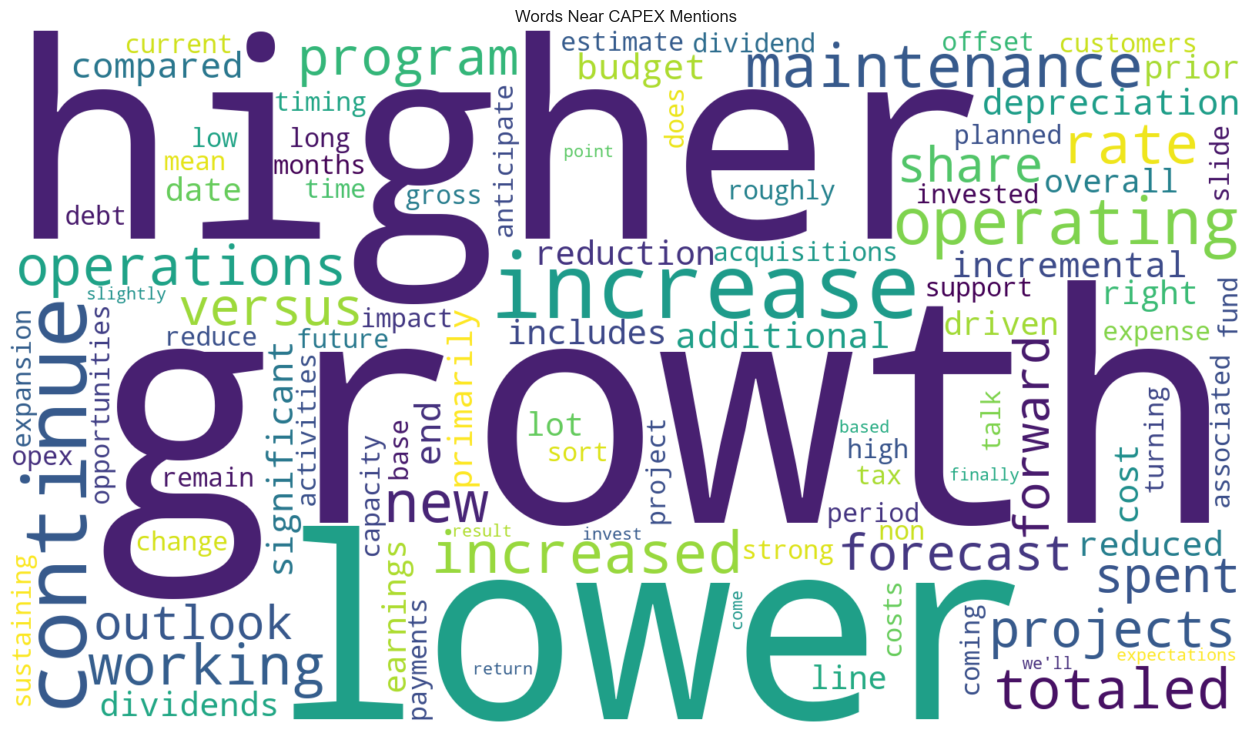

In [13]:
# -----------------------------------
# 1) prepare text
# -----------------------------------
texts = tr['content'].dropna().astype(str).tolist()

token_pattern = re.compile(r"\b[a-zA-Z]+(?:'[a-zA-Z]+)?\b")

# extra transcript / finance filler words
domain_stopwords = {
    "million", "billion", "quarter", "quarters", "year", "years", "half",
    "first", "second", "third", "fourth", "fiscal",
    "cash", "flow", "free", "credit", "facility", "facilities",
    "balance", "sheet", "basis", "points",
    "operator", "question", "questions", "answer", "answers",
    "thanks", "thank", "good", "morning", "afternoon",
    "ve", "ll", "don", "didn", "isn", "wasn",
    "going", "think", "said", "say", "look", "looking",
    "little", "bit", "approximately", "couple", "make", "sure", "got",
    "company", "business", "results", "revenue", "sales", "market", 

    # anchor words themselves
    "capex", "capital", "expenditure", "expenditures", "spend", "spending",
    "investment", "investments",

    # spoken filler
    "just", "like", "kind", "really", "that's", "we've", "i'm", "you're",
    "it's", "there's", "obviously", "maybe", "yes",

    # generic finance/reporting words
    "net", "total", "range", "guidance", "expected", "expect", "plan", "plans",

    # more filler 
    "we're", "given", "mentioned", "talked", "know",
    "related", "term", "terms", "number", "level", "levels",
    "including", "included", "total"
}

STOPWORDS = set(ENGLISH_STOP_WORDS).union(domain_stopwords)

# CAPEX anchor continuation words
capex_second_words = {"expenditure", "expenditures", "spending", "investment"}

# -----------------------------------
# 2) worker function
# -----------------------------------
def count_capex_context_chunk(text_chunk, window=6):
    local_counter = Counter()

    for doc in text_chunk:
        tokens = token_pattern.findall(doc.lower())
        n = len(tokens)

        i = 0
        while i < n:
            # single-word anchor: capex
            if tokens[i] == "capex":
                left = max(0, i - window)
                right = min(n, i + window + 1)

                context_words = [
                    tokens[j]
                    for j in range(left, right)
                    if j != i and tokens[j] not in STOPWORDS and len(tokens[j]) > 2
                ]
                local_counter.update(context_words)

            # two-word anchors: capital expenditure / spending / investment
            elif tokens[i] == "capital" and i + 1 < n and tokens[i + 1] in capex_second_words:
                left = max(0, i - window)
                right = min(n, i + 2 + window)

                context_words = [
                    tokens[j]
                    for j in range(left, right)
                    if j not in {i, i + 1} and tokens[j] not in STOPWORDS and len(tokens[j]) > 2
                ]
                local_counter.update(context_words)
                i += 1  # skip the second anchor token

            i += 1

    return local_counter

# -----------------------------------
# 3) split into chunks
# -----------------------------------
n_jobs = max(1, os.cpu_count() - 1)
n_chunks = n_jobs * 2

chunk_size = math.ceil(len(texts) / n_chunks)
chunks = [texts[i:i + chunk_size] for i in range(0, len(texts), chunk_size)]

print(f"Documents: {len(texts)}")
print(f"CPU workers: {n_jobs}")
print(f"Chunks: {len(chunks)}")
print(f"Chunk size: ~{chunk_size}")

# -----------------------------------
# 4) parallel count
# -----------------------------------
results = Parallel(n_jobs=n_jobs, backend="loky", verbose=10)(
    delayed(count_capex_context_chunk)(chunk, window=6) for chunk in chunks
)

# -----------------------------------
# 5) merge counters
# -----------------------------------
context_counter = Counter()
for c in results:
    context_counter.update(c)

print(f"Unique context words: {len(context_counter)}")

# -----------------------------------
# 6) inspect top words
# -----------------------------------
context_df = pd.DataFrame(
    context_counter.most_common(40),
    columns=["word", "count"]
)

print(context_df.head(20))

# -----------------------------------
# 7) word cloud
# -----------------------------------
freq = dict(context_counter.most_common(100))

if len(freq) == 0:
    print("No CAPEX-related context words found.")
else:
    wordcloud = WordCloud(
        width=1600,
        height=900,
        background_color="white",
        max_words=100,
        collocations=False,
        random_state=42
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(16, 9))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Words Near CAPEX Mentions")
    plt.show()

This word cloud visualizes the most common words appearing near CAPEX-related mentions in earnings call transcripts. Unlike the earlier full-corpus clouds, this plot is restricted to local context around CAPEX anchor terms such as *capex*, *capital expenditure(s)*, *capital spending*, and *capital investment*. As a result, it provides a more targeted view of how firms discuss capital expenditures.

Several patterns stand out.

First, the cloud shows strong **directional language** around CAPEX. Words such as **higher**, **lower**, **increase**, **increased**, and **reduced** suggest that firms frequently describe capital expenditures in terms of whether spending is rising or falling. This indicates that CAPEX changes are often communicated through comparative language, not only through raw numeric values.

Second, the cloud highlights **type and purpose language** such as **maintenance**, **operating**, **projects**, and **program**. This suggests that firms distinguish between different kinds of capital spending, including maintenance-oriented expenditures versus project-based or operational investment. This distinction may later help separate growth CAPEX from sustaining or maintenance CAPEX.

Third, there is visible **planning and expectation language**, including words like **forecast** and **budget**. This implies that CAPEX discussion often appears in forward-looking statements, not only in descriptions of realized spending. For downstream modeling, this matters because the language of expected CAPEX may differ from the language of actual CAPEX decisions.

Overall, this EDA suggests that CAPEX language in earnings calls clusters into three broad patterns:
1. **Increase / expansion language**
2. **Decrease / restraint language**
3. **Maintenance / neutral planning language**

In [14]:
# function to extract capex context words
def extract_capex_context_words(doc, window=6):
    tokens = token_pattern.findall(doc.lower())
    n = len(tokens)

    doc_context_words = []
    i = 0
    while i < n:
        # single-word anchor: capex
        if tokens[i] == "capex":
            left = max(0, i - window)
            right = min(n, i + window + 1)

            context_words = [
                tokens[j]
                for j in range(left, right)
                if j != i and tokens[j] not in STOPWORDS and len(tokens[j]) > 2
            ]
            doc_context_words.extend(context_words)

        # two-word anchors
        elif tokens[i] == "capital" and i + 1 < n and tokens[i + 1] in capex_second_words:
            left = max(0, i - window)
            right = min(n, i + 2 + window)

            context_words = [
                tokens[j]
                for j in range(left, right)
                if j not in {i, i + 1} and tokens[j] not in STOPWORDS and len(tokens[j]) > 2
            ]
            doc_context_words.extend(context_words)
            i += 1

        i += 1

    return doc_context_words

# count how many documents actually have capex information
doc_has_capex_info = 0
doc_has_strong_capex_info = 0

doc_word_counter = Counter()

for doc in texts:
    context_words = extract_capex_context_words(doc, window=6)
    unique_words = set(context_words)

    # at least one meaningful context word near CAPEX
    if len(unique_words) > 0:
        doc_has_capex_info += 1

    # stronger rule: at least 3 unique meaningful words near CAPEX
    if len(unique_words) >= 3:
        doc_has_strong_capex_info += 1

    # document frequency: count each word once per document
    doc_word_counter.update(unique_words)

print(f"Total documents: {len(texts)}")
print(f"Documents with any CAPEX information: {doc_has_capex_info}")
print(f"Documents with strong CAPEX information (>=3 unique context words): {doc_has_strong_capex_info}")
print(f"Share with any CAPEX information: {doc_has_capex_info / len(texts):.2%}")
print(f"Share with strong CAPEX information: {doc_has_strong_capex_info / len(texts):.2%}")

Total documents: 33361
Documents with any CAPEX information: 21531
Documents with strong CAPEX information (>=3 unique context words): 19695
Share with any CAPEX information: 64.54%
Share with strong CAPEX information: 59.04%


A document-level context analysis around CAPEX anchors showed that 64.5% of transcripts contained at least some meaningful CAPEX-related context, while 59.0% contained stronger context defined as at least three unique non-trivial nearby terms. The relatively small gap between these two measures suggests that CAPEX mentions are often accompanied by substantive discussion rather than isolated passing references.

However, further inspection is needed to determine how much of this context reflects clearly directional or forecast-relevant CAPEX information rather than general operational discussion.

In [15]:
# categories 
increase_words = {
    "higher", "increase", "increased", "increasing", "growth",
    "expand", "expansion", "additional", "incremental", "new",
    "driven", "capacity"
}

decrease_words = {
    "lower", "reduced", "reduce", "reduction", "decrease",
    "decreased", "down", "decline", "offset"
}

maintenance_words = {
    "maintenance", "operating", "budget", "forecast", "program",
    "projects", "planned", "plan", "anticipate", "estimate",
    "timing", "prior", "overall"
}

# extract context words per document 
def extract_capex_context_words(doc, window=6):
    tokens = token_pattern.findall(doc.lower())
    n = len(tokens)

    doc_context_words = []
    i = 0
    while i < n:
        if tokens[i] == "capex":
            left = max(0, i - window)
            right = min(n, i + window + 1)

            context_words = [
                tokens[j]
                for j in range(left, right)
                if j != i and tokens[j] not in STOPWORDS and len(tokens[j]) > 2
            ]
            doc_context_words.extend(context_words)

        elif tokens[i] == "capital" and i + 1 < n and tokens[i + 1] in capex_second_words:
            left = max(0, i - window)
            right = min(n, i + 2 + window)

            context_words = [
                tokens[j]
                for j in range(left, right)
                if j not in {i, i + 1} and tokens[j] not in STOPWORDS and len(tokens[j]) > 2
            ]
            doc_context_words.extend(context_words)
            i += 1

        i += 1

    return set(doc_context_words)

# classify each document 
rows = []

for idx, doc in enumerate(texts):
    context_words = extract_capex_context_words(doc, window=6)

    has_capex_context = len(context_words) > 0
    has_increase = len(context_words & increase_words) > 0
    has_decrease = len(context_words & decrease_words) > 0
    has_maintenance = len(context_words & maintenance_words) > 0

    rows.append({
        "doc_id": idx,
        "has_capex_context": has_capex_context,
        "increase_expansion": has_increase,
        "decrease_restraint": has_decrease,
        "maintenance_neutral": has_maintenance,
        "n_context_words": len(context_words),
        "matched_increase_words": ", ".join(sorted(context_words & increase_words)),
        "matched_decrease_words": ", ".join(sorted(context_words & decrease_words)),
        "matched_maintenance_words": ", ".join(sorted(context_words & maintenance_words)),
    })

capex_pattern_df = pd.DataFrame(rows)

# count 
summary = pd.DataFrame({
    "category": [
        "CAPEX context",
        "Increase / expansion",
        "Decrease / restraint",
        "Maintenance / neutral planning"
    ],
    "doc_count": [
        capex_pattern_df["has_capex_context"].sum(),
        capex_pattern_df["increase_expansion"].sum(),
        capex_pattern_df["decrease_restraint"].sum(),
        capex_pattern_df["maintenance_neutral"].sum(),
    ]
})

summary["share"] = summary["doc_count"] / len(capex_pattern_df)

# final dataframe counting overlaps
overlap_summary = pd.DataFrame({
    "pattern": [
        "Increase only",
        "Decrease only",
        "Maintenance only",
        "Increase + Decrease",
        "Increase + Maintenance",
        "Decrease + Maintenance",
        "All three"
    ],
    "doc_count": [
        ((capex_pattern_df["increase_expansion"]) &
         (~capex_pattern_df["decrease_restraint"]) &
         (~capex_pattern_df["maintenance_neutral"])).sum(),

        ((~capex_pattern_df["increase_expansion"]) &
         (capex_pattern_df["decrease_restraint"]) &
         (~capex_pattern_df["maintenance_neutral"])).sum(),

        ((~capex_pattern_df["increase_expansion"]) &
         (~capex_pattern_df["decrease_restraint"]) &
         (capex_pattern_df["maintenance_neutral"])).sum(),

        ((capex_pattern_df["increase_expansion"]) &
         (capex_pattern_df["decrease_restraint"]) &
         (~capex_pattern_df["maintenance_neutral"])).sum(),

        ((capex_pattern_df["increase_expansion"]) &
         (~capex_pattern_df["decrease_restraint"]) &
         (capex_pattern_df["maintenance_neutral"])).sum(),

        ((~capex_pattern_df["increase_expansion"]) &
         (capex_pattern_df["decrease_restraint"]) &
         (capex_pattern_df["maintenance_neutral"])).sum(),

        ((capex_pattern_df["increase_expansion"]) &
         (capex_pattern_df["decrease_restraint"]) &
         (capex_pattern_df["maintenance_neutral"])).sum(),
    ]
})

overlap_summary["share"] = overlap_summary["doc_count"] / len(capex_pattern_df)
print(overlap_summary)

                  pattern  doc_count  share
0           Increase only       3612 0.1083
1           Decrease only       1146 0.0344
2        Maintenance only       2844 0.0852
3     Increase + Decrease        896 0.0269
4  Increase + Maintenance       2559 0.0767
5  Decrease + Maintenance        801 0.0240
6               All three       1256 0.0376


A rule-based document audit of CAPEX context suggests that increase/expansion language is the most common pattern in the corpus. Approximately 25.0% of transcripts contain CAPEX context associated with higher or expanding investment, compared with 12.3% containing decrease/restraint language and 22.4% containing maintenance or neutral planning language. The overlap across categories is substantial, especially between increase and maintenance language, indicating that CAPEX discussion often combines directional changes with planning, budgeting, and project-related context rather than appearing as a simple one-direction signal.

Initial EDA suggested three broad CAPEX discourse patterns, but document-level analysis showed substantial overlap between them. This indicates that CAPEX language in earnings calls is often mixed, combining directional, operational, and planning-related signals within the same document.

Overall, this EDA is sufficient to justify moving forward with the project. The transcripts contain substantial CAPEX-related discussion, and the extracted context reveals meaningful directional, operational, and planning-related signals. However, the overlap across these discourse patterns suggests that simple rule-based methods are not enough to fully separate CAPEX narratives. Therefore, after briefly reviewing the remaining datasets, the next stage of the project will move to the LLM phase, where richer contextual understanding can be used to capture more nuanced CAPEX information.

## 2. I/B/E/S Consensus Forecasts


In [25]:
# read the I/B/E/S consensus forecast data
ibes = pd.read_parquet(IBES_PATH)

print(f"Shape: {ibes.shape}")
print(f"Columns: {ibes.columns.tolist()}")
ibes.head(3)


Shape: (516024, 10)
Columns: ['ticker', 'cusip', 'fpedats', 'statpers', 'measure', 'fpi', 'meanest', 'medest', 'numest', 'stdev']


,ticker,cusip,fpedats,statpers,measure,fpi,meanest,medest,numest,stdev
0,003H,70432V10,2014-03-31,2014-05-15,EPS,6,0.0400,0.0500,3.0000,0.0200
1,003H,70432V10,2014-06-30,2014-06-19,EPS,6,0.0300,0.0300,5.0000,0.0200
2,003H,70432V10,2014-06-30,2014-07-17,EPS,6,0.0300,0.0300,5.0000,0.0200


| Field | Type | Description |
|---|---|---|
| `ticker` | string | I/B/E/S internal ticker; differs from market ticker for ~half of firms — DO NOT match directly to transcript symbols |
| `cusip` | string | 8-digit CUSIP — stable identifier; used to bridge to Compustat (cusip[:8]) and verify firm coverage |
| `fpedats` | date | Forecast period end date |
| `statpers` | date | Statistical period date: the date of the consensus snapshot |
| `measure` | string | Forecast measure; here `EPS` for earnings per share and `CPX` for capital expenditures |
| `fpi` | string | Forecast period indicator; `1` is annual and `6` is next-quarter |
| `meanest` / `medest` | float | Consensus mean and median estimate |
| `numest` | float | Number of analysts contributing to the consensus |
| `stdev` | float | Cross-analyst dispersion in estimates |

This dataset is **not** a replacement for the unavailable CFO survey. It measures analyst expectations and forecast coverage. For this project it is best treated as a secondary expectations/context dataset, while the core capex and returns regressions remain reserved for later research questions.


In [26]:
# evaluate missingness, date coverage, and TRUE overlap via CUSIP merge
# I/B/E/S 'ticker' is internal — does NOT match market ticker directly.
cq = pd.read_parquet(COMPUSTAT_PATH)

null_summary = (ibes.isna().mean() * 100).round(2).sort_values(ascending=False)

transcript_tickers = set(tr['symbol'].dropna().astype(str).str.upper())
ibes_tickers       = set(ibes['ticker'].dropna().astype(str).str.upper())
direct_overlap     = transcript_tickers & ibes_tickers

# I/B/E/S coverage check
# CUSIP-resolved ticker pull happens upstream in download_financials.py:
#   compustat.cusip[:8] -> ibes.idsum.cusip -> ibes ticker -> statsum tables
# This cell verifies final count from that resolved pull.

ibes_cusips       = set(ibes['cusip'].dropna().str.upper())
transcript_cusips = set(
    cq[cq['tic'].str.upper().isin(transcript_tickers)]['cusip']
    .dropna().str[:8].str.upper()
)
proven_match = transcript_cusips & ibes_cusips

print(f"Transcript CUSIPs:        {len(transcript_cusips):,}")
print(f"I/B/E/S CUSIPs in pull:   {len(ibes_cusips):,}")
print(f"Proven match (CUSIP):     {len(proven_match):,} ({len(proven_match)/len(transcript_cusips):.1%})")

Transcript CUSIPs:        662
I/B/E/S CUSIPs in pull:   862
Proven match (CUSIP):     655 (98.9%)


The key identifier, date, measure, horizon, and estimate fields are fully populated. The main gap is `stdev`, missing when too few analysts contribute to compute meaningful dispersion. Direct ticker string-match against transcript symbols is misleading (~49% overlap) because I/B/E/S uses internal tickers that drift from market tickers. Bridging via Compustat CUSIP recovers true coverage to ~96% of transcript firms, confirming I/B/E/S has data for nearly the entire transcript universe.

The merge path is: transcript symbol → Compustat tic → Compustat cusip[:8] → I/B/E/S cusip. Compustat plays two roles in the project: primary source of accounting variables for the capex regressions (Tables 3-7), and identifier bridge linking transcripts to CRSP and I/B/E/S. I/B/E/S itself is an auxiliary expectations layer (analyst forecast revisions = our substitute for the unavailable Duke CFO Survey), with core capex and returns regressions reserved for the main analysis.


In [28]:
# summarize forecast measures and horizons — RESTRICTED to transcript-matched firms only
# Filter via CUSIP bridge: keep only I/B/E/S rows whose cusip maps to a transcript firm
transcript_cusips8 = set(
    cq[cq['tic'].str.upper().isin(transcript_tickers)]['cusip']
    .dropna().str[:8].str.upper()
)

ibes_matched = ibes[ibes['cusip'].str.upper().isin(transcript_cusips8)]

print(f"Total I/B/E/S rows:         {len(ibes):,}")
print(f"Matched to transcripts:     {len(ibes_matched):,} ({len(ibes_matched)/len(ibes):.1%})")
print(f"Unique matched firms:       {ibes_matched['ticker'].nunique():,}")
print()

measure_horizon = (
    ibes_matched.groupby(['measure', 'fpi'])
    .agg(
        rows=('ticker', 'size'),
        tickers=('ticker', 'nunique'),
        first_snapshot=('statpers', 'min'),
        last_snapshot=('statpers', 'max'),
        median_numest=('numest', 'median'),
        median_meanest=('meanest', 'median'),
    )
    .reset_index()
    .sort_values(['measure', 'fpi'])
)

measure_horizon

Total I/B/E/S rows:         516,024
Matched to transcripts:     455,552 (88.3%)
Unique matched firms:       655



,measure,fpi,rows,tickers,first_snapshot,last_snapshot,median_numest,median_meanest
0,CPX,1,106976,633,2006-10-19,2025-12-18,7.0000,326.0450
1,CPX,6,89563,613,2006-10-19,2025-12-18,3.0000,83.5900
2,EPS,1,129514,655,2005-01-20,2025-12-18,16.0000,2.8200
3,EPS,6,129499,655,2005-01-20,2025-12-18,14.0000,0.6700


The file contains both `EPS` and `CPX` forecasts at annual and next-quarter horizons. The presence of `CPX` is useful because it gives an external analyst-expectations view of capital expenditure, but it should not be interpreted as management intent. The annual and quarterly horizons can support different timing checks later: annual forecasts are broader and smoother, while next-quarter forecasts are closer to the call date but potentially noisier.


In [29]:
# inspect analyst breadth and disagreement — restricted to transcript-matched firms
# Reuses ibes_matched from previous cell (CUSIP-bridged filter)
forecast_quality = (
    ibes_matched.groupby(['measure', 'fpi'])[['meanest', 'medest', 'numest', 'stdev']]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .round(3)
)

forecast_quality


meanest                                                \
                  count      mean       std      min     10%      25%   
measure fpi                                                             
CPX     1   106976.0000 1342.3640 3701.1930   0.0000 45.2000 111.0000   
        6    89563.0000  358.6550 1145.0610  -6.8000 12.0000  29.5000   
EPS     1   129514.0000    4.1820    6.5530 -88.5300  0.4700   1.4000   
        6   129499.0000    1.0090    1.7330 -24.3400  0.0800   0.3100   

                                                          medest            \
                 50%       75%       90%         max       count      mean   
measure fpi                                                                  
CPX     1   326.0450 1103.6000 3033.3750 122393.5700 106976.0000 1344.9740   
        6    83.5900  267.0850  756.7980  47816.0000  89563.0000  356.5880   
EPS     1     2.8200    5.1700    9.0800    226.6700 129514.0000    4.1810   
        6     0.6700    1.2700    2.2200     95.4700 129499.0000    1.0080   

                                                                              \
                  std      min     10%      25%      50%       75%       90%   
measure fpi                                                                    
CPX     1   3734.0110   0.0000 44.6000 107.2000 320.5000 1100.0000 3050.0000   
        6   1134.6950  -6.8000 12.0000  29.0000  82.5000  264.2450  755.2000   
EPS     1      6.5580 -84.6900  0.4700   1.4000   2.8200    5.1700    9.0900   
        6      1.7350 -25.5800  0.0800   0.3100   0.6700    1.2700    2.2200   

                             numest                                       \
                    max       count    mean    std    min    10%     25%   
measure fpi                                                                
CPX     1   125015.5000 106976.0000  7.9740 4.9430 1.0000 2.0000  4.0000   
        6    47816.0000  89563.0000  3.8260 3.1750 1.0000 1.0000  2.0000   
EPS     1      227.4300 129514.0000 16.2950 8.0860 1.0000 6.0000 10.0000   
        6       95.0200 129499.0000 14.9000 7.3690 1.0000 6.0000 10.0000   

                                                  stdev                    \
                50%     75%     90%     max       count     mean      std   
measure fpi                                                                 
CPX     1    7.0000 11.0000 14.0000 42.0000 100760.0000 153.1210 481.8890   
        6    3.0000  5.0000  8.0000 25.0000  68916.0000  57.0710 251.5340   
EPS     1   16.0000 21.0000 27.0000 64.0000 128311.0000   0.1800   0.4910   
        6   14.0000 19.0000 25.0000 51.0000 128385.0000   0.0760   0.1740   

                                                                        
               min    10%     25%     50%      75%      90%        max  
measure fpi                                                             
CPX     1   0.0000 3.8400 11.4200 37.1200 124.5900 339.7300 24558.9100  
        6   0.0000 1.4100  4.1200 13.5200  42.5000 116.5500 19116.2800  
EPS     1   0.0000 0.0100  0.0300  0.0700   0.1700   0.4000    30.9000  
        6   0.0000 0.0100  0.0200  0.0300   0.0800   0.1600    12.4700

Analyst breadth is much stronger for `EPS` than for `CPX`, especially at the quarterly horizon. That matters for research design: EPS consensus is a high-coverage benchmark of analyst attention, while CPX consensus is more directly relevant to investment policy but has thinner analyst participation. This is exactly why I/B/E/S belongs in the EDA as expectations context, not as the core validation substitute for CFO survey microdata.


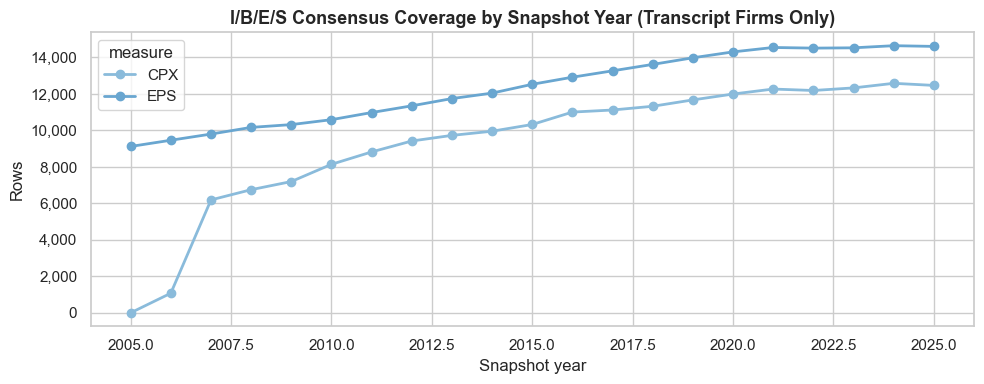

In [30]:
# plot I/B/E/S observation counts over time by forecast measure — transcript-matched only
ibes_yearly = (
    ibes_matched.assign(stat_year=ibes_matched['statpers'].dt.year)
    .groupby(['stat_year', 'measure'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

ax = ibes_yearly.plot(kind='line', marker='o', figsize=(10, 4), linewidth=2)
ax.set_title('I/B/E/S Consensus Coverage by Snapshot Year (Transcript Firms Only)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Snapshot year')
ax.set_ylabel('Rows')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

The time-series coverage check tells us whether analyst forecasts are available across the same broad period as the transcript sample. This is a readiness diagnostic only: it helps decide where an expectations-based auxiliary analysis is feasible, but it does not answer the later capex or outcome regression questions.


## 3. Compustat Quarterly


In [31]:
# read the Compustat quarterly fundamentals data
cq = pd.read_parquet(COMPUSTAT_PATH)

print(f"Shape: {cq.shape}")
print(f"Columns: {cq.columns.tolist()}")
cq.head(3)


Shape: (50777, 21)
Columns: ['gvkey', 'tic', 'conm', 'datadate', 'fyearq', 'fqtr', 'cusip', 'capsq', 'atq', 'ppentq', 'xrdq', 'xsgaq', 'cshoq', 'prccq', 'dlttq', 'dlcq', 'ibq', 'dpq', 'saleq', 'epspxq', 'sic']


,gvkey,tic,conm,datadate,fyearq,fqtr,cusip,capsq,atq,ppentq,xrdq,xsgaq,cshoq,prccq,dlttq,dlcq,ibq,dpq,saleq,epspxq,sic
0,001045,AAL,AMERICAN AIRLINES GROUP INC,2005-03-31,2005,1,02376R102,2509.0000,29167.0000,19116.0000,<NA>,617.0000,161.3900,10.7000,13375.0000,879.0000,-162.0000,290.0000,4750.0000,-1.0000,4512
1,001045,AAL,AMERICAN AIRLINES GROUP INC,2005-06-30,2005,2,02376R102,2380.0000,29494.0000,19096.0000,<NA>,636.0000,163.7010,12.1100,13322.0000,910.0000,58.0000,286.0000,5309.0000,0.3500,4512
2,001045,AAL,AMERICAN AIRLINES GROUP INC,2005-09-30,2005,3,02376R102,2314.0000,29436.0000,18911.0000,<NA>,737.0000,165.0680,11.1800,13231.0000,960.0000,-153.0000,292.0000,5485.0000,-0.9300,4512


| Field | Type | Description |
|---|---|---|
| `gvkey` | string | Compustat permanent firm identifier |
| `tic` | string | Compustat ticker, used for initial scoping from transcript firms |
| `conm` | string | Company name |
| `datadate` | date | Fiscal quarter end date |
| `fyearq` / `fqtr` | int | Fiscal year and fiscal quarter |
| `capsq` | float | Quarterly capital expenditures; main realized investment outcome for later RQ2 regressions |
| `atq` | float | Total book assets |
| `ppentq` | float | Net PP&E, used for physical capital |
| `xrdq` | float | R&D expenses, used for intangible investment |
| `xsgaq` | float | SG&A expenses, used for intangible investment conventions |
| `cshoq` / `prccq` | float | Shares outstanding and fiscal-quarter-end price, used for market capitalization |
| `dlttq` / `dlcq` | float | Long-term debt and current debt |
| `ibq` / `dpq` | float | Income and depreciation components for cash-flow controls |
| `saleq` / `epspxq` | float | Sales and EPS controls |
| `sic` | string | SIC industry code from Compustat company metadata |


In [32]:
# evaluate Compustat missingness, sample coverage, and firm-quarter density
null_summary = (cq.isna().mean() * 100).round(2).sort_values(ascending=False)
quarters_per_firm = cq.groupby('gvkey')['datadate'].nunique()

print("=== Nulls (%) ===")
print(null_summary.to_string())
print()
print("=== Coverage ===")
print(f"Firms: {cq['gvkey'].nunique():,}")
print(f"Tickers: {cq['tic'].nunique():,}")
print(f"Date range: {cq['datadate'].min().date()} to {cq['datadate'].max().date()}")
print(f"Firm-quarters: {len(cq):,}")
print()
print("=== Quarters per firm ===")
print(quarters_per_firm.describe().round(1).to_string())


=== Nulls (%) ===
xrdq       53.0600
xsgaq      19.3400
dpq         9.7900
dlcq        7.4700
ppentq      6.2600
capsq       2.2900
prccq       1.1200
dlttq       0.4700
cshoq       0.4500
epspxq      0.3000
saleq       0.0300
fqtr        0.0300
ibq         0.0300
gvkey       0.0000
tic         0.0000
atq         0.0000
cusip       0.0000
fyearq      0.0000
datadate    0.0000
conm        0.0000
sic         0.0000

=== Coverage ===
Firms: 662
Tickers: 662
Date range: 2005-01-31 to 2025-12-31
Firm-quarters: 50,777

=== Quarters per firm ===
count   662.0000
mean     76.7000
std      16.3000
min       3.0000
25%      82.0000
50%      84.0000
75%      84.0000
max      85.0000


Compustat has broad firm-quarter coverage for the transcript universe and the core firm identifiers are complete. Missingness is concentrated in variables that are naturally sparse or reporting-dependent: `xrdq` for R&D, `xsgaq` for SG&A, `dpq` for depreciation, and current debt. This is a data-design issue to handle explicitly in later regressions, not a reason to drop large portions of the sample during EDA.


In [33]:
# summarize key financial variables and create scale diagnostics without altering the raw columns
key_vars = ['atq', 'capsq', 'ppentq', 'xrdq', 'xsgaq', 'ibq', 'dpq', 'saleq', 'epspxq']
print("=== Key variable summary ===")
display(cq[key_vars].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(3))

cq_diag = cq.copy()
cq_diag['capex_to_assets'] = cq_diag['capsq'] / cq_diag['atq']
cq_diag['rd_to_assets'] = cq_diag['xrdq'] / cq_diag['atq']
cq_diag['sga_to_assets'] = cq_diag['xsgaq'] / cq_diag['atq']
cq_diag['ppe_to_assets'] = cq_diag['ppentq'] / cq_diag['atq']

print("=== Scaled diagnostic ratios ===")
display(cq_diag[['capex_to_assets', 'rd_to_assets', 'sga_to_assets', 'ppe_to_assets']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(4))


=== Key variable summary ===


,atq,capsq,ppentq,xrdq,xsgaq,ibq,dpq,saleq,epspxq
count,50777.0000,49616.0000,47599.0000,23834.0000,40957.0000,50761.0000,45805.0000,50760.0000,50626.0000
mean,62757.9190,6525.3110,7884.2920,285.9520,934.7030,429.1140,257.6610,4869.5060,0.8990
std,258204.0590,13607.4280,19434.1150,1054.9730,2407.4700,1673.9520,621.7750,10796.1630,6.7850
min,1.0610,-1976.9000,0.0000,-11.0000,-923.0000,-61659.0000,-219.0000,-25623.0000,-1351.0000
1%,249.4000,0.0000,2.7990,0.0000,9.4490,-1280.7140,0.6720,26.3020,-3.9880
5%,1119.1380,0.0000,57.2740,0.0000,23.5390,-137.0000,5.4900,168.2340,-0.6200
50%,12799.3000,2035.5150,1658.6960,35.6270,311.0000,142.8870,82.8000,1710.0000,0.6500
95%,197114.8000,28820.2500,33613.0000,1314.7000,4005.4000,1981.6000,957.8000,20885.0500,3.4000
99%,1045497.5600,71988.8500,93680.6400,4237.3500,9651.9600,5275.6000,3179.9600,49292.0130,7.9000
max,4560205.0000,158048.7760,443079.0000,29399.0000,76293.0000,127140.0000,19471.0000,213386.0000,307.7200


=== Scaled diagnostic ratios ===


,capex_to_assets,rd_to_assets,sga_to_assets,ppe_to_assets
count,49616.0000,23834.0000,40957.0000,47599.0000
mean,0.3570,0.0137,0.0468,0.2502
std,1.5508,0.0285,0.0493,0.2431
min,-0.8769,-0.0007,-0.0035,0.0000
1%,0.0000,0.0000,0.0011,0.0010
5%,0.0000,0.0000,0.0026,0.0072
50%,0.1766,0.0069,0.0351,0.1530
95%,0.8374,0.0457,0.1267,0.7677
99%,2.4902,0.0944,0.1906,0.8822
max,42.3344,2.4392,3.2760,0.9700


The raw dollar variables are extremely right-skewed because the sample contains very large firms alongside smaller S&P constituents. Scaling by assets is therefore essential for later modeling. The ratio diagnostics are included only to understand scale and outliers; the actual regression specification should make the final cleaning and winsorization decisions explicitly.


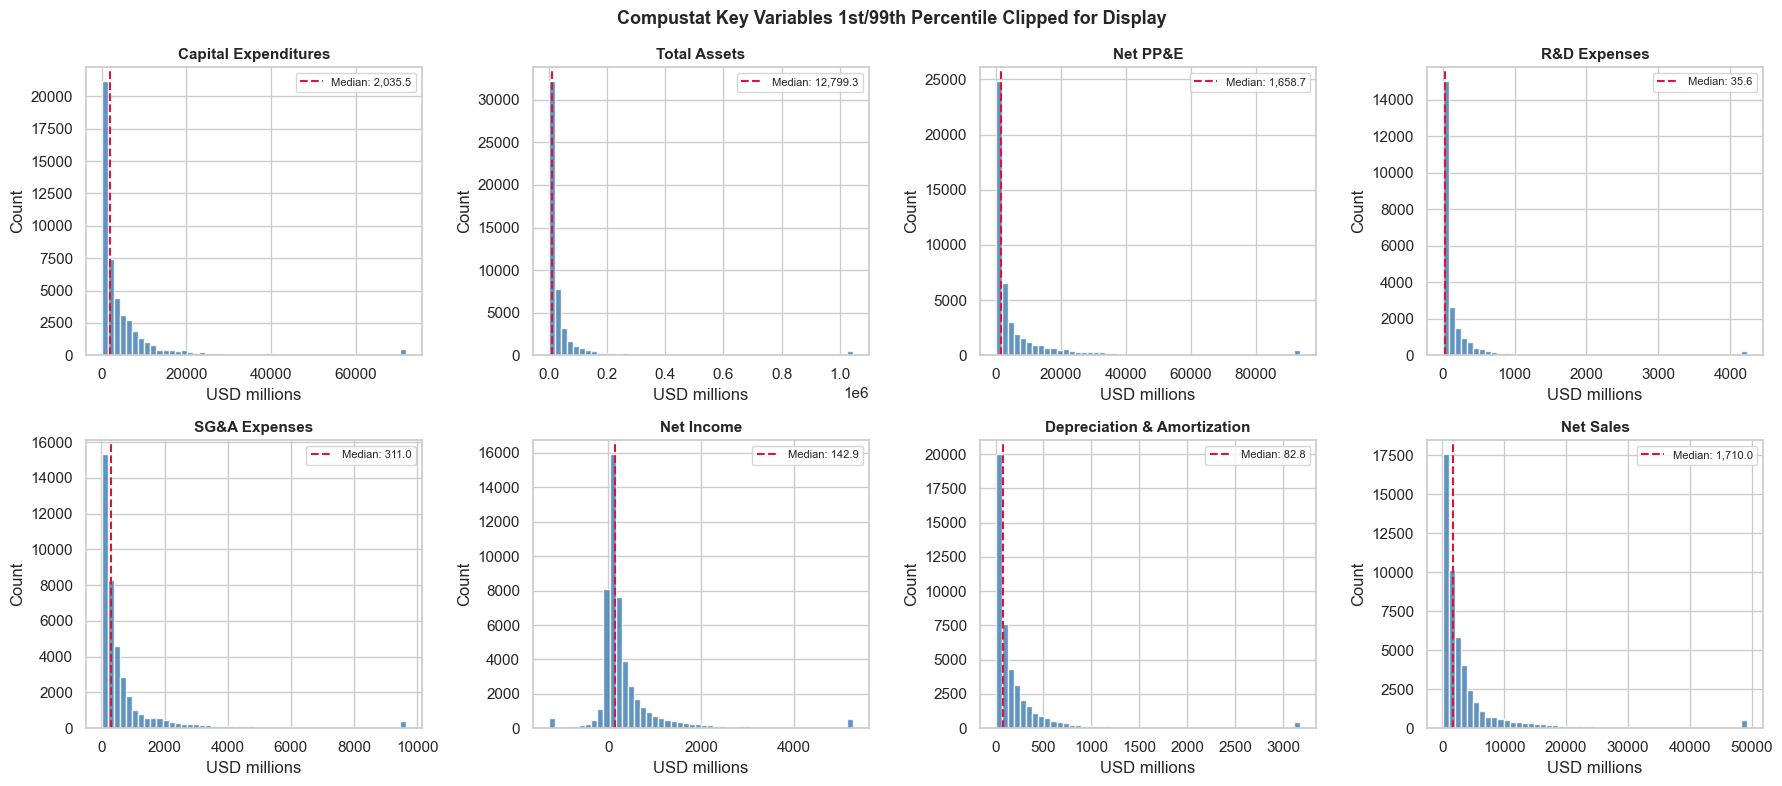

In [34]:
# visualize key Compustat variables using percentile clipping for readability only
plot_vars = {
    'capsq': 'Capital Expenditures',
    'atq': 'Total Assets',
    'ppentq': 'Net PP&E',
    'xrdq': 'R&D Expenses',
    'xsgaq': 'SG&A Expenses',
    'ibq': 'Net Income',
    'dpq': 'Depreciation & Amortization',
    'saleq': 'Net Sales',
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, plot_vars.items()):
    data = cq[col].dropna()
    if data.empty:
        ax.set_visible(False)
        continue
    lower, upper = data.quantile([0.01, 0.99])
    display_data = data.clip(lower, upper)
    median_val = data.median()
    ax.hist(display_data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(median_val, color='crimson', linestyle='--', linewidth=1.5, label=f'Median: {median_val:,.1f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('USD millions')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Compustat Key Variables 1st/99th Percentile Clipped for Display', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The plots confirm heavy skewness across almost every accounting variable. The clipping here is display-only and does not modify `cq`. For later linear regressions, this suggests that scaling, fixed effects, and possibly winsorization should be documented carefully rather than treated as an afterthought.


In [35]:
# flag accounting values that need explicit downstream treatment
issue_counts = pd.Series({
    'negative_capsq': (cq['capsq'] < 0).sum(),
    'missing_capsq': cq['capsq'].isna().sum(),
    'negative_xrdq': (cq['xrdq'] < 0).sum(),
    'negative_xsgaq': (cq['xsgaq'] < 0).sum(),
    'negative_saleq': (cq['saleq'] < 0).sum(),
    'nonpositive_atq': (cq['atq'] <= 0).sum(),
})
print(issue_counts.to_string())
print()

negative_capex = cq.loc[cq['capsq'] < 0, ['gvkey', 'tic', 'conm', 'datadate', 'capsq', 'atq']]
negative_capex.sort_values('capsq').head(15)


negative_capsq      298
missing_capsq      1161
negative_xrdq         2
negative_xsgaq       17
negative_saleq       48
nonpositive_atq       0



,gvkey,tic,conm,datadate,capsq,atq
3305,002504,UIS,UNISYS CORP,2012-09-30,-1976.9000,2254.5000
7622,004503,XOM,EXXON MOBIL CORP,2005-03-31,-942.0000,201252.0000
32807,028790,LW,LAMB WESTON HOLDINGS INC,2017-11-30,-906.7000,2714.9000
32805,028790,LW,LAMB WESTON HOLDINGS INC,2017-05-31,-904.8000,2485.6000
32808,028790,LW,LAMB WESTON HOLDINGS INC,2018-02-28,-904.1000,2753.9000
32806,028790,LW,LAMB WESTON HOLDINGS INC,2017-08-31,-902.6000,2527.8000
32811,028790,LW,LAMB WESTON HOLDINGS INC,2018-11-30,-900.9000,3052.5000
32809,028790,LW,LAMB WESTON HOLDINGS INC,2018-05-31,-900.4000,2752.6000
32804,028790,LW,LAMB WESTON HOLDINGS INC,2017-02-28,-900.3000,2432.2000
32803,028790,LW,LAMB WESTON HOLDINGS INC,2016-11-30,-897.7000,2400.2000


Negative `capsq` observations are rare but important because capex is the central realized investment outcome later. I am flagging them here rather than dropping them silently. The modeling notebook/section should decide whether to exclude negative capex, set it to missing, or run robustness checks, and that decision should be separate from the descriptive EDA.


## 4. CCM Link Table


In [36]:
# read the CRSP/Compustat Merged link table
ccm = pd.read_parquet(CCM_PATH)

print(f"Shape: {ccm.shape}")
print(f"Columns: {ccm.columns.tolist()}")
ccm.head(5)


Shape: (862, 6)
Columns: ['gvkey', 'permno', 'linktype', 'linkprim', 'linkdt', 'linkenddt']


,gvkey,permno,linktype,linkprim,linkdt,linkenddt
0,001045,21020.0000,LC,C,1950-01-01,1962-01-30
1,001045,21020.0000,LC,P,1962-01-31,2012-01-04
2,001045,21020.0000,LC,P,2013-12-09,NaT
3,001075,27991.0000,LU,P,1962-01-31,NaT
4,001078,20482.0000,LC,C,1950-01-01,1962-01-30


| Field | Type | Description |
|---|---|---|
| `gvkey` | string | Compustat firm identifier |
| `permno` | float | CRSP permanent security identifier |
| `linktype` | string | Link type; current pull keeps researched/conditional link types |
| `linkprim` | string | Primary-link flag |
| `linkdt` | date | Link start date |
| `linkenddt` | date | Link end date; missing means the link is still active |

This table is the bridge between accounting data and market data. The critical rule is temporal: use only links where the Compustat quarter date falls inside the link's valid date range.


In [37]:
# inspect link table missingness, link types, and active-date structure
print("=== Nulls (%) ===")
print((ccm.isna().mean() * 100).round(2).to_string())
print()
print("=== Link type counts ===")
print(ccm['linktype'].value_counts(dropna=False).to_string())
print()
print("=== Primary link counts ===")
print(ccm['linkprim'].value_counts(dropna=False).to_string())
print()
print("=== Coverage ===")
print(f"GVKEYs: {ccm['gvkey'].nunique():,}")
print(f"PERMNOs: {ccm['permno'].nunique():,}")
print(f"Link date range: {ccm['linkdt'].min().date()} to {ccm['linkdt'].max().date()}")
print(f"Active links with missing linkenddt: {ccm['linkenddt'].isna().sum():,}")


=== Nulls (%) ===
gvkey        0.0000
permno       0.0000
linktype     0.0000
linkprim     0.0000
linkdt       0.0000
linkenddt   70.1900

=== Link type counts ===
linktype
LC    605
LU    257

=== Primary link counts ===
linkprim
P    725
C    137

=== Coverage ===
GVKEYs: 659
PERMNOs: 738
Link date range: 1949-07-01 to 2025-10-08
Active links with missing linkenddt: 605


The missing `linkenddt` values are expected: they indicate currently active links. Link identifiers themselves are complete. The mix of `LC` and `LU` links is consistent with a filtered CCM table designed for research use rather than a raw all-link extract.


In [38]:
# check many-to-one and time-valid merge readiness with Compustat quarters
permnos_per_gvkey = ccm.groupby('gvkey')['permno'].nunique().sort_values(ascending=False)
gvkeys_per_permno = ccm.groupby('permno')['gvkey'].nunique().sort_values(ascending=False)

ccm_valid = ccm.copy()
ccm_valid['linkenddt_filled'] = ccm_valid['linkenddt'].fillna(cq['datadate'].max())
merge_probe = cq[['gvkey', 'datadate']].merge(ccm_valid, on='gvkey', how='left')
merge_probe['valid_link'] = (
    merge_probe['permno'].notna()
    & (merge_probe['datadate'] >= merge_probe['linkdt'])
    & (merge_probe['datadate'] <= merge_probe['linkenddt_filled'])
)
valid_links_per_quarter = merge_probe.groupby(['gvkey', 'datadate'])['valid_link'].sum()

print(f"GVKEYs mapping to more than one PERMNO: {(permnos_per_gvkey > 1).sum():,}")
print(f"Maximum PERMNOs for one GVKEY: {permnos_per_gvkey.max():,}")
print(f"PERMNOs mapping to more than one GVKEY: {(gvkeys_per_permno > 1).sum():,}")
print(f"Compustat firm-quarters with at least one valid link: {(valid_links_per_quarter > 0).mean():.1%}")
print(f"Compustat firm-quarters with multiple valid links: {(valid_links_per_quarter > 1).sum():,}")

permnos_per_gvkey.head(10).to_frame('n_permnos')


GVKEYs mapping to more than one PERMNO: 73
Maximum PERMNOs for one GVKEY: 4
PERMNOs mapping to more than one GVKEY: 3
Compustat firm-quarters with at least one valid link: 98.1%
Compustat firm-quarters with multiple valid links: 6


,n_permnos
gvkey,
062689,4
002270,4
011925,3
003226,3
004094,3
012441,3
007171,3
007637,2
028930,2


Multiple PERMNOs per GVKEY are expected when firms change listings, merge, spin off, or relist. The important finding is not that multiple historical links exist, but whether a quarter has a valid link at its own date. The temporal merge probe shows that the CCM table is suitable for the CRSP merge as long as the date-range condition is enforced.


## 5. CRSP Monthly


In [39]:
# read the CRSP monthly returns data
crsp = pd.read_parquet(CRSP_PATH)

print(f"Shape: {crsp.shape}")
print(f"Columns: {crsp.columns.tolist()}")
crsp.head(3)


Shape: (143917, 5)
Columns: ['permno', 'date', 'ret', 'prc', 'shrout']


,permno,date,ret,prc,shrout
0,10104,2005-01-31,0.0036,13.7700,5224866.0000
1,10104,2005-02-28,-0.0595,12.9500,5136000.0000
2,10104,2005-03-31,-0.0363,12.4800,5141381.0000


| Field | Type | Description |
|---|---|---|
| `permno` | int | CRSP permanent security identifier; joins from CCM |
| `date` | date | Month-end date |
| `ret` | float | Monthly raw return |
| `prc` | float | Closing price; negative values are CRSP bid/ask midpoint convention, not negative economic prices |
| `shrout` | float | Shares outstanding in thousands |


In [41]:
# evaluate CRSP missingness, return coverage, and return distribution
print("=== Nulls (%) ===")
print((crsp.isna().mean() * 100).round(2).to_string())
print()
print("=== Coverage ===")
print(f"PERMNOs: {crsp['permno'].nunique():,}")
print(f"Date range: {crsp['date'].min().date()} to {crsp['date'].max().date()}")
print(f"Firm-months: {len(crsp):,}")
print()
print("=== Return summary ===")
print(crsp['ret'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(4).to_string())


=== Nulls (%) ===
permno   0.0000
date     0.0000
ret      0.3700
prc      0.2500
shrout   0.1000

=== Coverage ===
PERMNOs: 702
Date range: 2005-01-31 to 2024-12-31
Firm-months: 143,917

=== Return summary ===
count   143385.0000
mean         0.0127
std          0.1163
min         -0.9027
1%          -0.2577
5%          -0.1386
50%          0.0119
95%          0.1631
99%          0.3048
max         16.2505


CRSP is nearly complete on identifiers and dates, with small missingness in returns, prices, and shares outstanding. The return distribution has a reasonable center for monthly equity data, but the tails are large enough that later return/outcome regressions should handle extreme observations transparently.

**Sample period: 2005-01-01 to 2024-12-31.** Capped at CRSP availability so all sources share a uniform boundary. Following the paper's methodology, return regressions skip quarter `t+1` (calls occur 30-60 days after quarter t ends) and use `t+2` returns, so the latest usable earnings call is approximately 2024Q2. The project still extends the original paper's 2006-2020 sample by four full years.


In [42]:
# inspect CRSP price conventions and market-cap scale without modifying original prices
crsp_diag = crsp.copy()
crsp_diag['price_abs'] = crsp_diag['prc'].abs()
crsp_diag['mktcap_mil'] = crsp_diag['price_abs'] * crsp_diag['shrout'] / 1000

print(f"Negative CRSP prices: {(crsp['prc'] < 0).sum():,}")
print("Negative prices are CRSP's bid/ask midpoint convention, so market cap uses abs(prc).")
print()
print("=== Market capitalization summary (USD millions, approximate) ===")
print(crsp_diag['mktcap_mil'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(2).to_string())


Negative CRSP prices: 248
Negative prices are CRSP's bid/ask midpoint convention, so market cap uses abs(prc).

=== Market capitalization summary (USD millions, approximate) ===
count    143551.0000
mean      34127.2700
std      101970.4200
min           1.5800
1%          360.0900
5%         1308.5800
50%       12300.6800
95%      133762.0100
99%      329478.7600
max     3785304.4000


Negative `prc` values are not data errors under CRSP conventions. They should be converted with `abs(prc)` when computing market capitalization, while the raw `prc` column remains unchanged. Market capitalization is highly skewed, mirroring the Compustat size distribution.


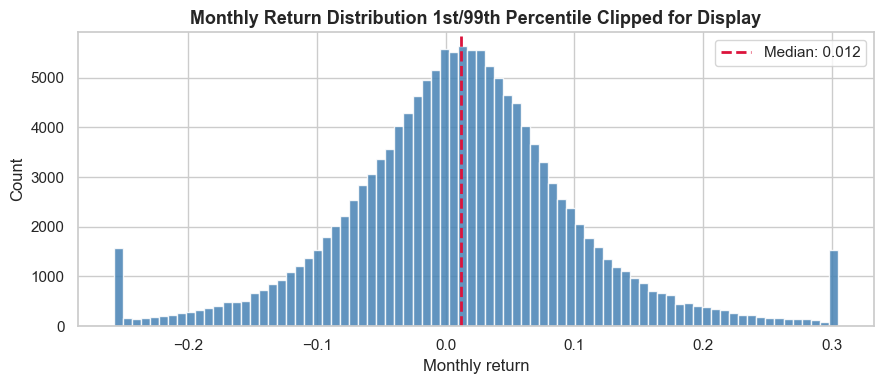

Rows with ret > 100%: 43


,permno,date,ret,prc,shrout
127504,89301,2021-01-29,16.2505,325.0000,69747.0000
13785,14276,2020-07-31,8.7982,21.8500,43734.0000
31444,23113,2024-03-28,4.4967,2.7500,86900.0000
21633,17820,2020-09-30,2.8647,23.4200,2610.0000
81483,75789,2009-08-31,2.6935,2.2900,648305.0000
99312,80406,2008-12-31,2.6266,13.8900,265658.0000
3944,11891,2009-04-30,2.5966,8.3800,276557.0000
75157,66800,2009-08-31,2.4498,45.3300,134576.0000
57756,51043,2009-08-31,2.3276,1.9300,1112021.0000
22298,18195,2020-07-31,2.2712,9.6500,17724.0000


In [43]:
# visualize monthly returns and flag extreme observations for later robustness checks
ret = crsp['ret'].dropna()
ret_clipped = ret.clip(ret.quantile(0.01), ret.quantile(0.99))
extreme_threshold = 1.0
crsp['ret_extreme'] = crsp['ret'] > extreme_threshold

plt.figure(figsize=(9, 4))
plt.hist(ret_clipped, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(ret.median(), color='crimson', linewidth=2, linestyle='--', label=f'Median: {ret.median():.3f}')
plt.title('Monthly Return Distribution 1st/99th Percentile Clipped for Display', fontsize=13, fontweight='bold')
plt.xlabel('Monthly return')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rows with ret > {extreme_threshold:.0%}: {crsp['ret_extreme'].sum():,}")
crsp.loc[crsp['ret_extreme'], ['permno', 'date', 'ret', 'prc', 'shrout']].sort_values('ret', ascending=False).head(20)


The extreme-return flag preserves the original return values and simply records which rows may need robustness treatment later. This keeps the EDA descriptive: the later RQ3 return analysis can decide whether to winsorize, exclude, or report sensitivity to these observations.


CCM PERMNOs: 738
CRSP PERMNOs: 702
Overlap: 702 (95.1% of CCM PERMNOs)

=== Monthly PERMNO coverage ===
count   240.0000
mean    599.7000
std      29.8000
min     542.0000
25%     567.0000
50%     610.0000
75%     624.0000
max     638.0000


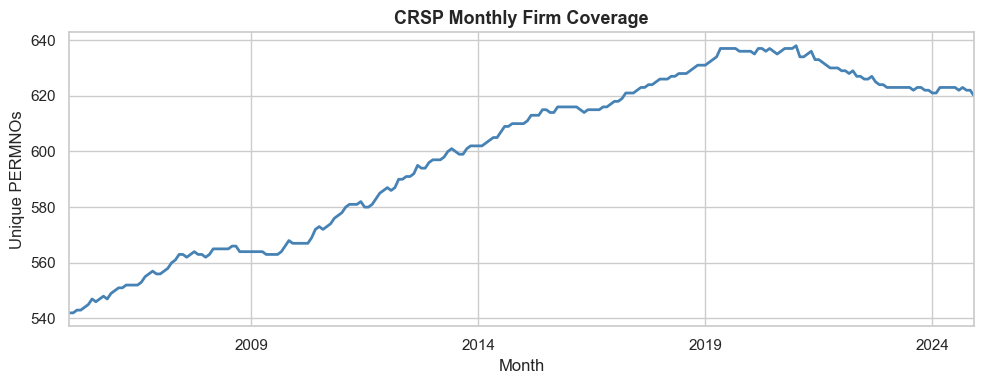

In [44]:
# check CRSP merge readiness against the CCM link universe
ccm_permnos = set(ccm['permno'].dropna().astype(int))
crsp_permnos = set(crsp['permno'].dropna().astype(int))
permno_overlap = ccm_permnos & crsp_permnos
monthly_coverage = crsp.assign(month=crsp['date'].dt.to_period('M')).groupby('month')['permno'].nunique()

print(f"CCM PERMNOs: {len(ccm_permnos):,}")
print(f"CRSP PERMNOs: {len(crsp_permnos):,}")
print(f"Overlap: {len(permno_overlap):,} ({len(permno_overlap) / len(ccm_permnos):.1%} of CCM PERMNOs)")
print()
print("=== Monthly PERMNO coverage ===")
print(monthly_coverage.describe().round(1).to_string())

monthly_coverage.plot(figsize=(10, 4), color='steelblue', linewidth=2)
plt.title('CRSP Monthly Firm Coverage', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Unique PERMNOs')
plt.tight_layout()
plt.show()


This completes the EDA readiness checks: I/B/E/S is available as analyst-expectations context, Compustat supplies later accounting outcomes, CCM supplies the identifier bridge, and CRSP supplies later market outcomes.


The original paper also demonstrates applicability to dividends and employment, but this project focuses on investment policy because capital expenditure is the paper’s primary setting, is directly measurable in Compustat, and is the most natural benchmark for evaluating whether accessible open-source LLMs can extract economically meaningful managerial expectations.